# On Analyzing Real World Time Series for Forecasting Wesad Heart Rate Data
- TUTORIAL: [simplestockpredictionautoregression.ipynb](https://gist.github.com/DanielWicz/e2f90648e46da599080fed70d11cc09c)
- I also have the code in the play folder. Have my code resemble his.
- With splitting data


## TODOs
- [x] Autoget list of lags
- [x] Reconfigure AR model to train same model every lag (and NOT a new model per lag)
- [x] Reconstruct my plots to be like his
- [x] Fix Table of Contents/Steps

Follow: https://github.com/Brinkley97/applied_time_series_and_machine_learning/blob/development/framework_for_time_series_data/nlp_ts/paper-daily-sse_stock-ts_models.ipynb

In [1]:
import os
import sys
# Get the current working directory of the notebook
notebook_dir = os.getcwd()

# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../../framework_for_time_series_data/tslearn/'))

from collections import namedtuple
from data_plotter import InterpolatePlotter
from data_loader import build_stock_uts, build_any_univariate_time_series
from ts_models_no_retrain import augment_retrain_predictions, AR_Model, MA_Model, ARMA_Model, ARIMA_Model, EvaluationMetric
from time_series import TimeSeriesFactory, UnivariateTimeSeries

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Stock Data Analysis with Forecasts

1. Load Raw Data
2. Plot Raw Data
3. Get Descriptive Statistics (ie: mean, median, range, etc) of Raw Data
4. Check Stationarity of Raw Data
5. Plot Autocorrelation and Partial Autocorrelation of Raw Data
6. Initialize Autoregressive `AR(p)` Model
7. Predict + Plot Actual Forecasts vs Predicted Forecasts for Raw Data Forecasts
8. Follow-up

### Load Raw Data

In [2]:
file = "../datasets/WESAD/S2/S2_E4_Data/HR.csv"

hr_ts = build_any_univariate_time_series(file)
hr_ts

UnivariateTimeSeries(Observations)

In [3]:
hr_ts_df = hr_ts.get_as_df()
hr_ts_df

,Observations
Timestamp,
0,1.00
1,101.00
2,106.50
3,95.33
4,90.25
...,...
7861,81.38
7862,82.03
7863,82.67


### Plot Raw Data

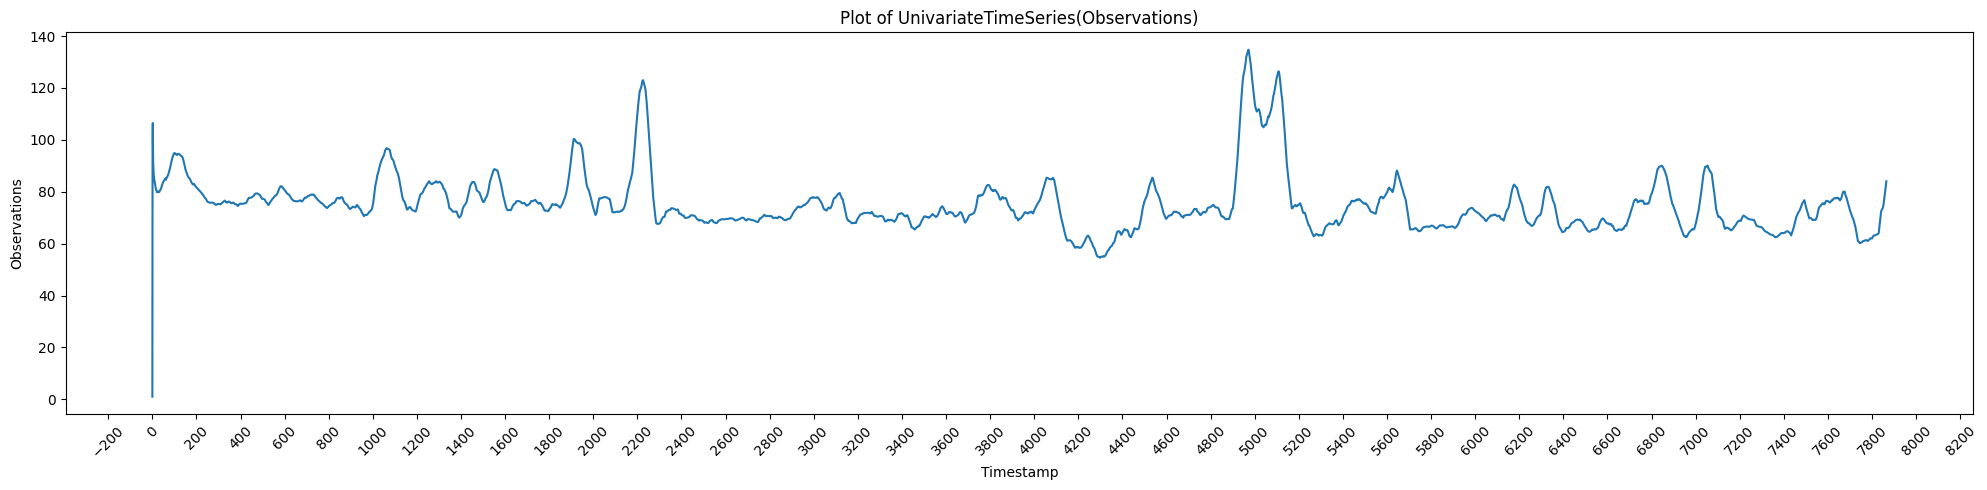

In [4]:
hr_ts.plot(tick_skip=200)

### Get Descriptive Statistics of Raw Data

In [5]:
hr_ts.get_statistics(time_type='seconds', type_of_data='heart rate value')

/Users/detraviousjamaribrinkley/Documents/Development/self/applied_time_series_and_machine_learning/misc/play/../../framework_for_time_series_data/tslearn/time_series.py:194: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  count_value = int(stats.loc['count'])


,Observations
total seconds,7866.000000
most recent date,4972.000000
inception date,0.000000
lowest heart rate value,1.000000
highest heart rate value,134.770000
average heart rate value,75.090000
range,133.770000
heart rate value volatility,10.770000
25th percentile heart rate value,69.180000
median heart rate value,73.100000


### Check Stationarity of Raw Data

- With financial data, we expect it to be non-stationary.
    - Can we verify this non-stationary with plotting the Autocorrelation?

In [6]:
hr_ts.stationarity_test(hr_ts_df)

ADF Statistic: -7.209819
p-value: 0.000000 < 0.05 , so reject null-hypothesis as the TS is stationary
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


### Plot Autocorrelation and Partial Autocorrelation of Raw Data

/Users/detraviousjamaribrinkley/Documents/Development/self/applied_time_series_and_machine_learning/misc/play/../../framework_for_time_series_data/tslearn/time_series.py:401: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.variance()[0]
/Users/detraviousjamaribrinkley/Documents/Development/self/applied_time_series_and_machine_learning/misc/play/../../framework_for_time_series_data/tslearn/time_series.py:402: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean = self.mean()[0]
/Users/detraviousjamaribrinkley/Documents/Development/self/applied_time_series_and_machine_learning/misc/play/../../framework_for_time

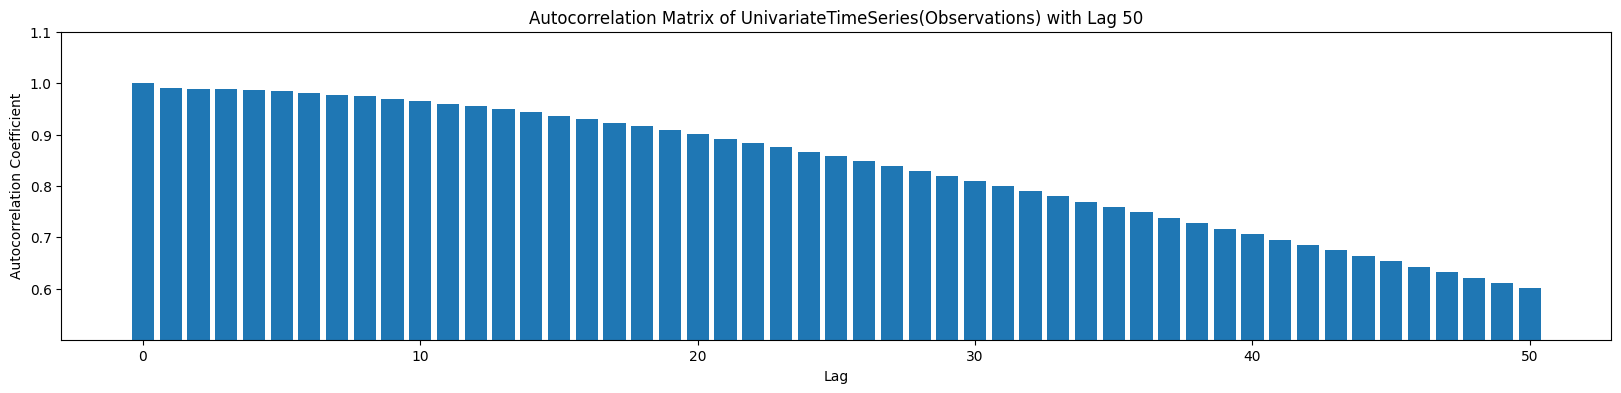

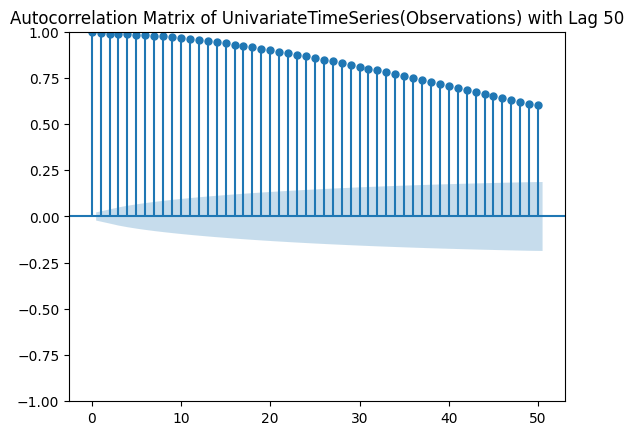

In [7]:
hr_ts.plot_autocorrelation(50)

- Above, the data is highly correlated which means that the k-th lag observation has some impact on the most recent observation.

In [8]:
threshold_acorrs = hr_ts.autocorrelation_with_threshold()
# threshold_acorrs

/Users/detraviousjamaribrinkley/Documents/Development/self/applied_time_series_and_machine_learning/misc/play/../../framework_for_time_series_data/tslearn/time_series.py:422: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return autocovariance / self.variance()[0]


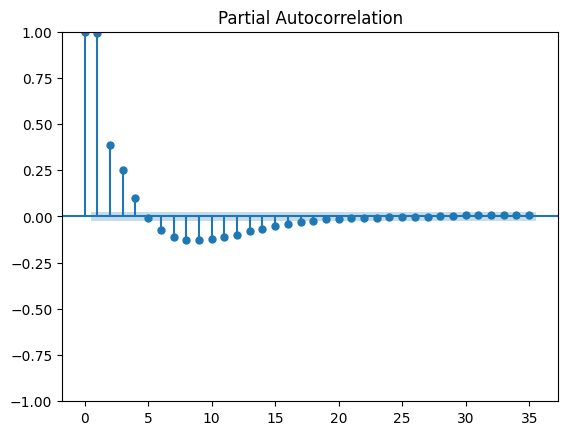

In [9]:
hr_ts.plot_partial_autocorrelation(35)

- The Partial ACorr rapidly decays as lag observation 2, so if we use an MA, we'd go with AR(2).

In [10]:
len(hr_ts.get_series()), hr_ts.get_series()

(7866, array([  1.  , 101.  , 106.5 , ...,  82.67,  83.35,  84.03]))

### Initialize Autoregressive AR(p) Model

- How to determine the proper lag value? Look at the Partial ACor plot.

In [11]:
train_hr_df = hr_ts.get_slice_with_percentage(train_percent=.8, both_train_test=False, train_or_test="Train")
train_hr_df.get_as_df()

Train size is 6292


,UnivariateTimeSeries(Observations)[1:6292]
Timestamp,
0,1.00
1,101.00
2,106.50
3,95.33
4,90.25
...,...
6287,70.67
6288,70.72
6289,70.75


In [12]:
test_hr_df = hr_ts.get_slice_with_percentage(train_percent=.8, both_train_test=False, train_or_test="Test")
test_hr_df.get_as_df()

Test size is 1574


,UnivariateTimeSeries(Observations)[1574:7866]
Timestamp,
6292,70.88
6293,70.90
6294,70.87
6295,71.03
6296,71.23
...,...
7861,81.38
7862,82.03
7863,82.67


In [13]:
len(hr_ts.get_as_df()) == len(train_hr_df.get_as_df()) + len(test_hr_df.get_as_df())

True

In [14]:
last_N_train_df = train_hr_df.get_as_df().iloc[-10: , :]
last_N_train_df

,UnivariateTimeSeries(Observations)[1:6292]
Timestamp,
6282,70.15
6283,70.23
6284,70.32
6285,70.45
6286,70.60
6287,70.67
6288,70.72
6289,70.75
6290,70.82


In [15]:
N_test_df = len(test_hr_df)
N_test_df

1574

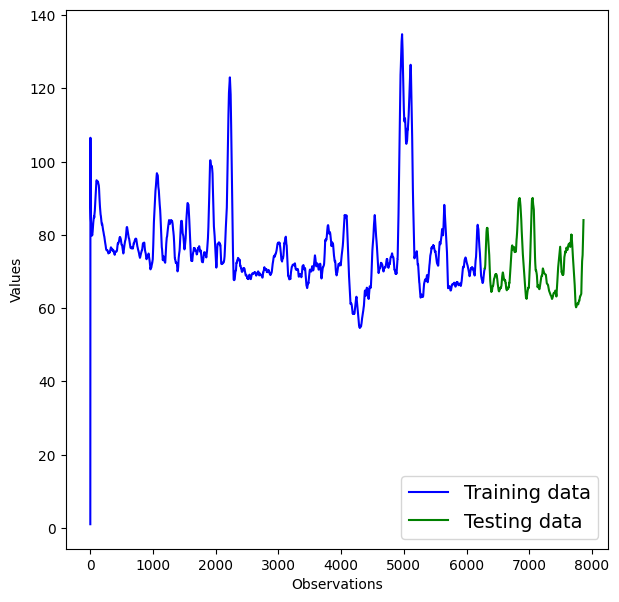

In [16]:
scatter_type = False
data_prediction_plots = InterpolatePlotter()
data_prediction_plots.plot_ts_training_and_testing_data(train_hr_df.get_as_df(), test_hr_df.get_as_df(), scatter_type)

In [17]:
lag_p = 2

In [18]:
train_hr_values = train_hr_df.values
train_values = augment_retrain_predictions(train_hr_values)
len(train_values), train_values, len(last_N_train_df)

(6292, array([  1.  , 101.  , 106.5 , ...,  70.75,  70.82,  70.85]), 10)

In [19]:
no_retrain_name = ' - no retrain'
no_retrain_bool = False

ar_no_retrain_model_class = AR_Model(no_retrain_name, lag_p=len(last_N_train_df))
ar_no_retrain_model_class.train(train_values)
ar_no_retrain_model_class.summary()

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/ar_model.py:498: RuntimeWarning: divide by zero encountered in matmul
  return self._y.squeeze() - (self._x @ params).squeeze()
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/ar_model.py:498: RuntimeWarning: overflow encountered in matmul
  return self._y.squeeze() - (self._x @ params).squeeze()
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/ar_model.py:498: RuntimeWarning: invalid value encountered in matmul
  return self._y.squeeze() - (self._x @ params).squeeze()
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/ar_model.py:516: RuntimeWarning: divide by zero encountered in matmul
  ssr = resid @ resid
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/ar_model.py:516: RuntimeWarning: overflow encountered in matmul
  ssr =

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                 6292
Model:                    AutoReg(10)   Log Likelihood                8573.987
Method:               Conditional MLE   S.D. of innovations              0.062
Date:                Fri, 15 Aug 2025   AIC                         -17123.973
Time:                        16:01:14   BIC                         -17043.028
Sample:                            10   HQIC                        -17095.929
                                 6292                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0382      0.005      6.988      0.000       0.027       0.049
y.L1           2.0156      0.013    159.751      0.000       1.991       2.040
y.L2          -1.0640      0.028    -37.480      0.000      -1.120      -1.008
y.L3           0.0684      0.031      2.177      0.029       0.007       0.130
y.L4          -0.0504      0.031     -1.606      0.108      -0.112       0.011
y.L5           0.0498      0.031      1.589      0.112      -0.012       0.111
y.L6          -0.0254      0.031     -0.810      0.418      -0.087       0.036
y.L7          -0.0043      0.030     -0.141      0.887      -0.064       0.055
y.L8           0.0165      0.022      0.749      0.454      -0.027       0.060
y.L9          -0.0073      0.009     -0.781      0.435      -0.025       0.011
y.L10          0.0005      0.002      0.300      0.764      -0.003       0.004
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             1.0164           -0.0169j            1.0165           -0.0026
AR.2             1.0164           +0.0169j            1.0165            0.0026
AR.3            -2.1534           -0.0000j            2.1534           -0.5000
AR.4            -1.2102           -1.4705j            1.9045           -0.3596
AR.5            -1.2102           +1.4705j            1.9045            0.3596
AR.6             0.5577           -1.9771j            2.0543           -0.2062
AR.7             0.5577           +1.9771j            2.0543            0.2062
AR.8             2.0756           -0.8383j            2.2385           -0.0611
AR.9             2.0756           +0.8383j            2.2385            0.0611
AR.10           11.4516           -0.0000j           11.4516           -0.0000
------------------------------------------------------------------------------
"""

In [20]:
test_hr_values = test_hr_df.values
test_values = augment_retrain_predictions(test_hr_values)
len(test_values), test_values

(1574, array([70.88, 70.9 , 70.87, ..., 82.67, 83.35, 84.03]))

In [21]:
# retrain false
ar_predictions = ar_no_retrain_model_class.make_predictions(train_values, test_values)
ar_predictions
all_predictions_df = ar_no_retrain_model_class.model_predictions_to_df(test_hr_df.get_as_df(), ar_predictions)
all_predictions_df

,UnivariateTimeSeries(Observations)[1574:7866],AR Model - no retrain
Timestamp,,
6292,70.88,70.878768
6293,70.90,70.909711
6294,70.87,70.941497
6295,71.03,70.975743
6296,71.23,71.011598
...,...,...
7861,81.38,76.125940
7862,82.03,76.125940
7863,82.67,76.125940


In [22]:
ar_model_pred_name = f"{ar_no_retrain_model_class.__name__()}{no_retrain_name}"
ar_predictions_df = all_predictions_df.loc[:, ar_model_pred_name]
ar_predictions_df

Timestamp
6292    70.878768
6293    70.909711
6294    70.941497
6295    70.975743
6296    71.011598
          ...    
7861    76.125940
7862    76.125940
7863    76.125940
7864    76.125940
7865    76.125940
Name: AR Model - no retrain, Length: 1574, dtype: float64

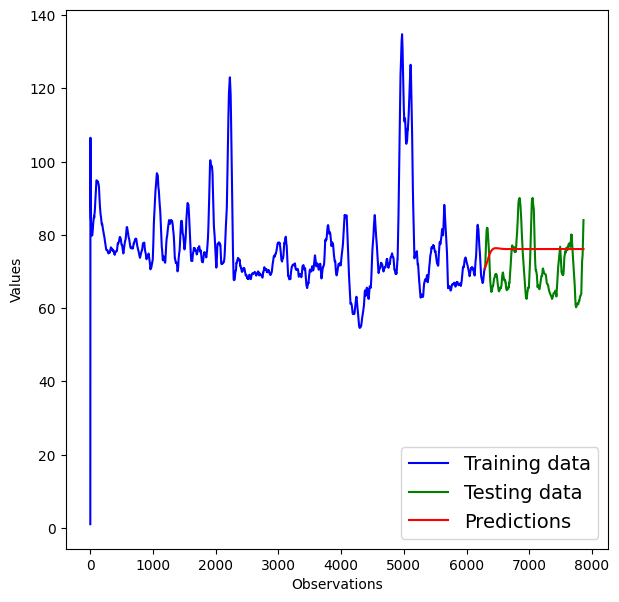

In [23]:
data_prediction_plots.plot_ts_training_and_testing_data(train_hr_df.get_as_df(), test_hr_df.get_as_df(), scatter_type, ar_predictions_df)

Follow: https://github.com/Brinkley97/applied_time_series_and_machine_learning/blob/development/framework_for_time_series_data/nlp_ts/paper-daily-sse_stock-ts_models.ipynb

In [24]:
EvaluationMetric.eval_mse(test_hr_df.get_as_df(), ar_predictions_df, per_element=False)
EvaluationMetric.eval_rmse(test_hr_df.get_as_df(), ar_predictions_df, per_element=False)

Test MSE: 76.974
Test RMSE: 8.774


#### Initialize Model: `MA(q)`

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Test MSE: 76.974
Test RMSE: 8.774


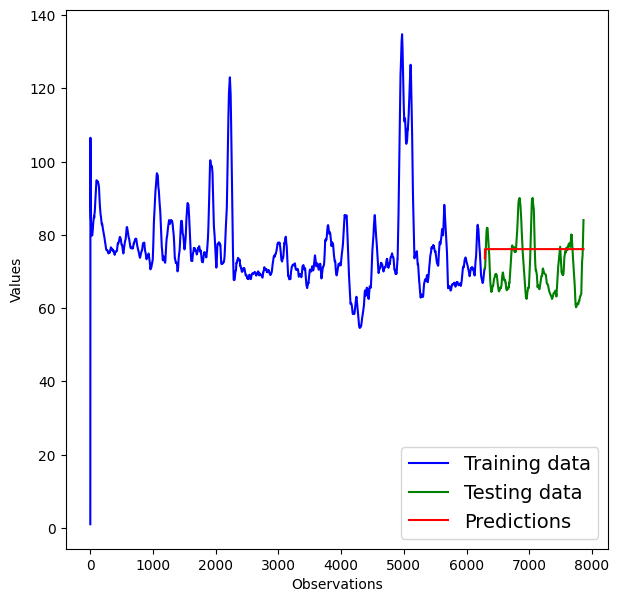

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Test MSE: 6137.307
Test RMSE: 78.341


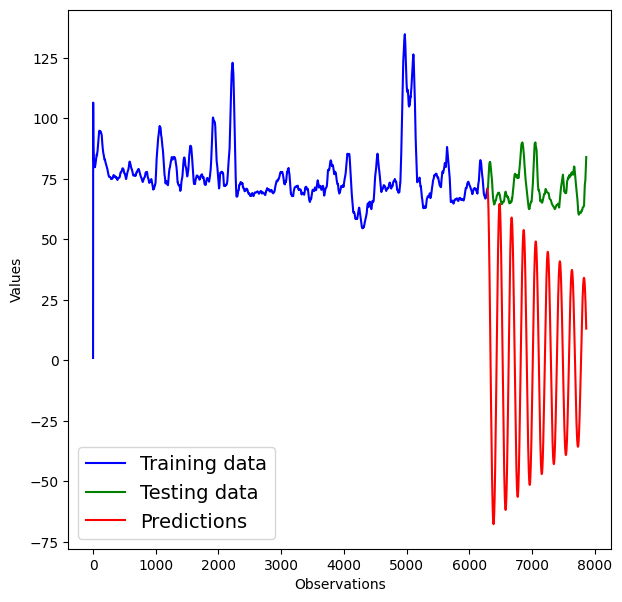

/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/detraviousjamaribrinkley/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


Test MSE: 107552.021
Test RMSE: 327.951


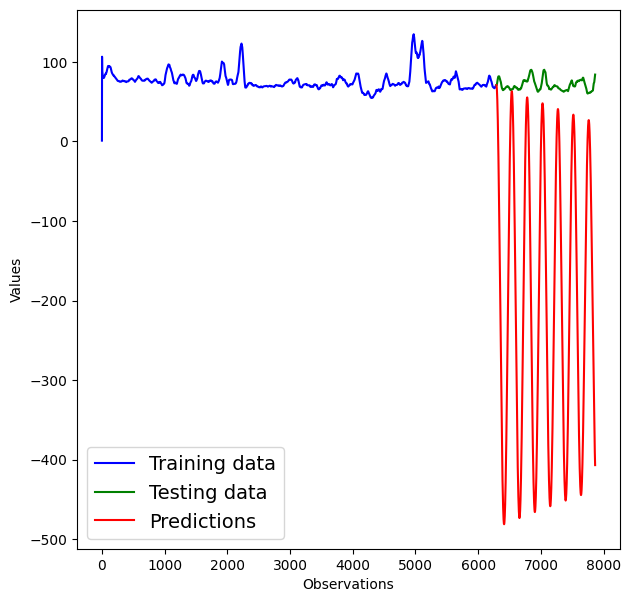

In [25]:
error_q = 1 # MA
ma_model_class = MA_Model(no_retrain_name, error_q=error_q)
ma_model_class.train(train_values)
ma_model_class.summary()

ma_model_pred_name = f"{ma_model_class.__name__()}{no_retrain_name}"

ma_predictions_no_retrain = ma_model_class.make_predictions(train_values, test_values)
# all_predictions_df = ma_model_class.model_predictions_to_df(test_hr_df.get_as_df(), ma_predictions_no_retrain)
all_predictions_df[ma_model_pred_name] = ma_predictions_no_retrain
ma_predictions_df = all_predictions_df.loc[:, ma_model_pred_name]

EvaluationMetric.eval_mse(all_predictions_df.iloc[:, 0], all_predictions_df.iloc[:, 1], per_element=False)
EvaluationMetric.eval_rmse(all_predictions_df.iloc[:, 0], all_predictions_df.iloc[:, 1], per_element=False)

data_prediction_plots.plot_ts_training_and_testing_data(train_hr_df.get_as_df(), test_hr_df.get_as_df(), scatter_type, ma_predictions_df)

arma_model_class = ARMA_Model(no_retrain_name, lag_p, error_q)
arma_model_class.train(train_values)
arma_model_class.summary()

# retrain false
arma_model_pred_name = f"{arma_model_class.__name__()}{no_retrain_name}"
arma_predictions_no_retrain = arma_model_class.make_predictions(train_values, test_values)
# all_predictions_df = arma_model_class.model_predictions_to_df(test_hr_df.get_as_df(), arma_predictions_no_retrain)
all_predictions_df[arma_model_pred_name] = arma_predictions_no_retrain
arma_predictions_df = all_predictions_df.loc[:, arma_model_pred_name]

EvaluationMetric.eval_mse(all_predictions_df.iloc[:, 0], all_predictions_df.iloc[:, 3], per_element=False)
EvaluationMetric.eval_rmse(all_predictions_df.iloc[:, 0], all_predictions_df.iloc[:, 3], per_element=False)

data_prediction_plots.plot_ts_training_and_testing_data(train_hr_df.get_as_df(), test_hr_df.get_as_df(), scatter_type, arma_predictions_df)


diff_d = 1

arima_model_class = ARIMA_Model(no_retrain_name, lag_p, error_q, diff_d)
trained_arima_model = arima_model_class.train(train_values)
# trained_arima_model.summary()

arima_model_pred_name = f"{arima_model_class.__name__()}{no_retrain_name}"
arima_predictions_no_retrain = arima_model_class.make_predictions(train_values, test_values)
# all_raw_predictions_df = arima_model_class.model_predictions_to_df(test_values, arima_predictions)
all_predictions_df[arima_model_pred_name] = arima_predictions_no_retrain
arima_predictions_df = all_predictions_df.loc[:, arima_model_pred_name]


EvaluationMetric.eval_mse(all_predictions_df.iloc[:, 0], all_predictions_df.iloc[:, 4], per_element=False)
EvaluationMetric.eval_rmse(all_predictions_df.iloc[:, 0], all_predictions_df.iloc[:, 4], per_element=False)

data_prediction_plots.plot_ts_training_and_testing_data(train_hr_df.get_as_df(), test_hr_df.get_as_df(), scatter_type=False, predictions_df=arima_predictions_df)


In [26]:
all_predictions_df

,UnivariateTimeSeries(Observations)[1574:7866],AR Model - no retrain,MA Model - no retrain,ARMA Model - no retrain,ARIMA Model - no retrain
Timestamp,,,,,
6292,70.88,70.878768,73.549922,70.760132,70.697698
6293,70.90,70.909711,76.105371,70.594841,70.363238
6294,70.87,70.941497,76.105371,70.354376,69.846881
6295,71.03,70.975743,76.105371,70.039064,69.149007
6296,71.23,71.011598,76.105371,69.649313,68.270119
...,...,...,...,...,...
7861,81.38,76.125940,76.105371,17.064653,-394.020221
7862,82.03,76.125940,76.105371,16.102873,-397.427397
7863,82.67,76.125940,76.105371,15.124825,-400.709006
